In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
doc_sent = pd.read_csv("../data/output/DOC_SENT.csv", sep="|")
theta = pd.read_csv("../data/output/LDA_THETA_ENRICHED.csv", sep=",")
lib = pd.read_csv("../data/archive/key_english.csv", sep=",")

In [55]:
lib.columns = ["book_number", "book_name", "testament", "genre"]

In [56]:
theta[["book_number", "chapter", "verse"]] = (
    theta["Document"]
    .str.split("_", expand=True)
    .astype(int)
)

theta.rename(
    columns={"Dominant_Topic": "dominant_topic"},
    inplace=True
)

print(theta.columns)

Index(['T00', 'T01', 'T02', 'T03', 'T04', 'Document', 'BookNum', 'Book',
       'dominant_topic', 'book_number', 'chapter', 'verse'],
      dtype='object')


In [57]:
theta["Document"].head()

0     10_10_1
1    10_10_10
2    10_10_11
3    10_10_12
4    10_10_13
Name: Document, dtype: object

In [58]:
doc_topic = doc_sent.merge(
    theta[["book_number", "chapter", "verse", "dominant_topic"]],
    on=["book_number", "chapter", "verse"],
    how="left"
)

doc_topic.head()

,book_number,chapter,verse,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative,token_count,dominant_topic
0,1,1,1,0.000000,0.100000,0.0,0.100000,0.100000,0.000000,0.000000,0.100000,0.100000,0.000000,10,T02
1,1,1,2,0.034483,0.034483,0.0,0.068966,0.034483,0.034483,0.000000,0.034483,0.068966,0.034483,29,T00
2,1,1,3,0.000000,0.090909,0.0,0.090909,0.090909,0.000000,0.000000,0.090909,0.090909,0.000000,11,T01
3,1,1,4,0.058824,0.176471,0.0,0.176471,0.176471,0.058824,0.058824,0.176471,0.176471,0.058824,17,T01
4,1,1,5,0.045455,0.045455,0.0,0.090909,0.045455,0.045455,0.000000,0.045455,0.045455,0.045455,22,T02


In [59]:
emo_cols = [
    "anger", "anticipation", "disgust", "fear",
    "joy", "sadness", "surprise", "trust",
    "positive", "negative"
]

topic_sentiment = (
    doc_topic
    .groupby("dominant_topic")[emo_cols]
    .mean()
)

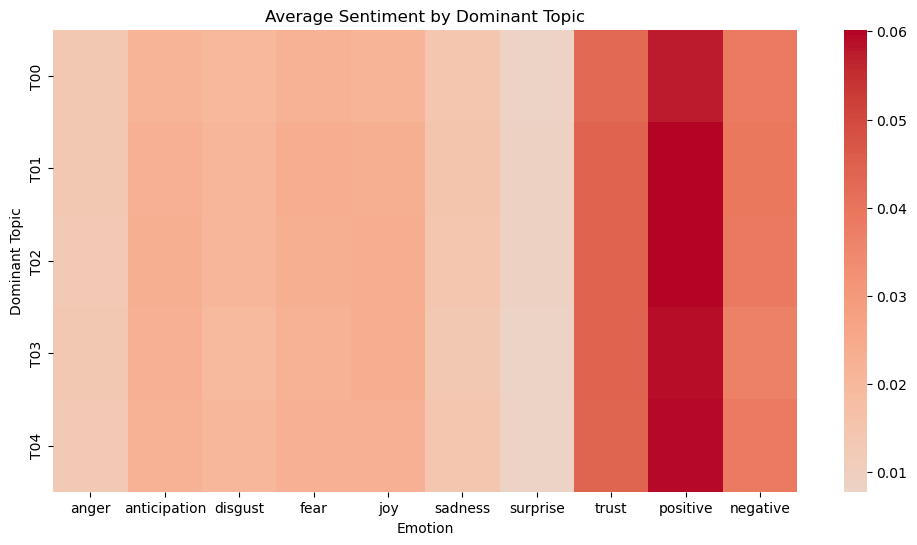

In [60]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    topic_sentiment,
    cmap="coolwarm",
    center=0
)

plt.title("Average Sentiment by Dominant Topic")
plt.xlabel("Emotion")
plt.ylabel("Dominant Topic")
plt.show()

In [61]:
topic_counts = doc_topic["dominant_topic"].value_counts()
print(topic_counts)

dominant_topic
T00    10757
T01     6768
T02     4646
T04     4471
T03     4460
Name: count, dtype: int64


In [62]:
doc_topic.groupby("dominant_topic")[emo_cols].std()

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,positive,negative
dominant_topic,,,,,,,,,,
T00,0.027954,0.034176,0.032479,0.034692,0.036423,0.028932,0.020355,0.050222,0.057970,0.046494
T01,0.027948,0.036618,0.033011,0.035879,0.038953,0.029464,0.022955,0.052947,0.060380,0.046740
T02,0.028406,0.037670,0.033281,0.036950,0.040316,0.029475,0.022886,0.053243,0.061532,0.046833
T03,0.029933,0.037559,0.032465,0.035913,0.040343,0.028358,0.021337,0.053297,0.061058,0.046250
T04,0.028685,0.036473,0.032792,0.035886,0.038246,0.029170,0.020715,0.052220,0.061506,0.046421


In [63]:
global_mean = doc_topic[emo_cols].mean()

In [64]:
topic_diff = topic_sentiment - global_mean

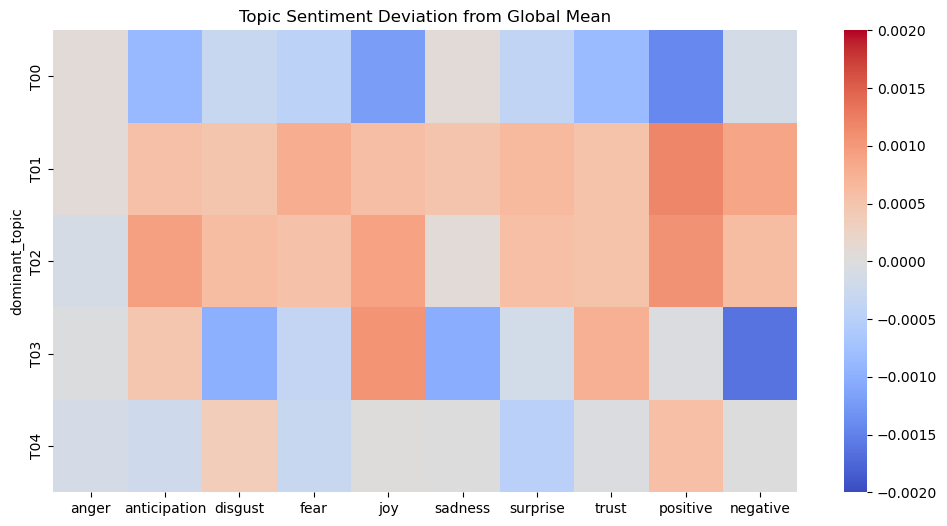

In [66]:
plt.figure(figsize=(12,6))
sns.heatmap(
    topic_diff,
    cmap="coolwarm",
    center=0,
    vmin=-0.002,
    vmax=0.002
)
plt.title("Topic Sentiment Deviation from Global Mean")
plt.show()

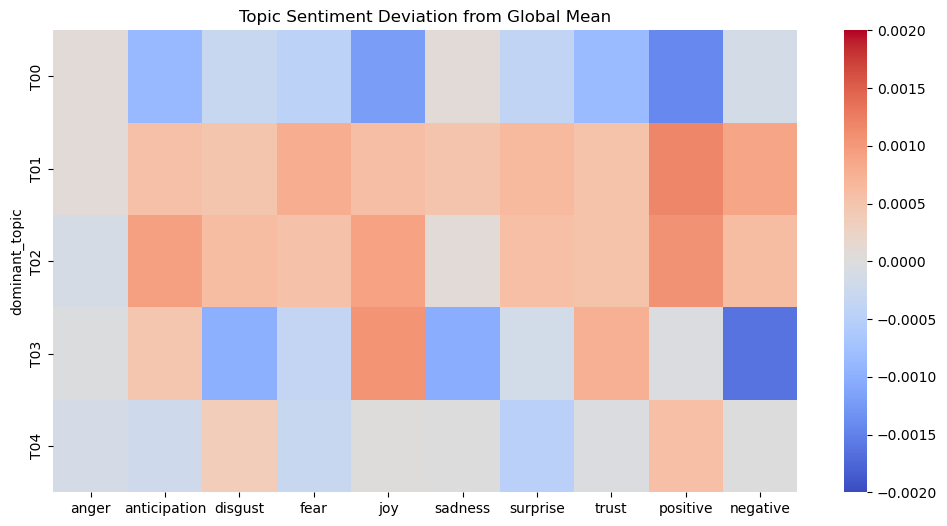

Saved to: /Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/graphs/riff1_topic_sentiment_deviation.png


In [67]:
import os

graph_path = "/Users/nicholasthornton/Downloads/DS 5001/DS-5001-Bible-Analysis-Final-Project/graphs"

os.makedirs(graph_path, exist_ok=True)

plt.figure(figsize=(12,6))
sns.heatmap(
    topic_diff,
    cmap="coolwarm",
    center=0,
    vmin=-0.002,
    vmax=0.002
)
plt.title("Topic Sentiment Deviation from Global Mean")

save_file = os.path.join(graph_path, "riff1_topic_sentiment_deviation.png")
plt.savefig(save_file, dpi=300, bbox_inches="tight")

plt.show()

print("Saved to:", save_file)

This heatmap shows how average sentiment within each LDA-derived topic in the King James Version Bible deviates from the overall corpus mean. Because raw sentiment magnitudes are relatively uniform across books of the Bible, plotting deviations allows us to see subtle but consistent emotional distinctions tied to thematic structure.

Topics T01 and T02 exhibit elevated positive and trust sentiment relative to the global mean, along with slightly higher anticipation. In the context of the KJV Bible, this pattern is consistent with covenantal, prophetic, or exhortative material, where themes of divine promise, faithfulness, and future hope are prominent. These topics likely capture passages emphasizing reassurance, redemption, or divine assurance, which aligns with elevated trust and positive lexical markers in the NRC lexicon.

Topic T00, by contrast, trends below the global mean in joy and positive sentiment while remaining close to neutral across other emotions. This suggests material that is more narrative or descriptive in tone rather than overtly celebratory or affirming. In biblical structure, this could correspond to genealogical records, legal material, or historical accounts where emotional language is less pronounced.

Topic T03 displays elevated joy and surprise but reduced overall positive sentiment. In the KJV corpus, this combination is suggestive of dramatic narrative episodes, such as moments of divine intervention, prophetic revelation, or sudden reversal. The rise in surprise combined with lower net positivity may reflect emotionally intense but morally complex passages, including judgment narratives or conflict-driven storytelling.

Topic T04 shows slightly elevated disgust and muted trust relative to the corpus mean. Within the biblical context, this pattern aligns plausibly with legal, purity, or condemnation passages, including descriptions of idolatry, sin, or ritual impurity, which frequently invoke lexicon categories associated with disgust in the NRC framework.

Although the numerical deviations are small, their directional consistency suggests that LDA topic structure in the KJV Bible correlates with subtle emotional signatures. Thematic groupings are not defined primarily by polarity, but they do carry systematic shifts in trust, anticipation, joy, and disgust. Emotional tone therefore appears as a secondary but meaningful layer embedded within thematic and narrative organization in the biblical corpus.